<a href="https://colab.research.google.com/github/AnikaRanjan/MDST/blob/main/week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SHAP Explanations

### **All exercises will be using your chosen dataset**

## Install necessary libraries. We will be using SHAP for week 7

In [81]:
!pip install pandas numpy matplotlib seaborn scikit-learn shap

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


## Exercises

### SHAP Docs, ML Interpretability Book, and Demo for Reference

#### [SHAP](https://shap.readthedocs.io/en/latest/)
#### [ML Interpretability](https://christophm.github.io/interpretable-ml-book/)
#### [Demo](https://mdst-ai-in-healthcare.streamlit.app/)


Import your **model from the previous week (before MAPIE)**

In [82]:
# TODO: use joblib.load to import the model
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NewestData.csv')
df
model = joblib.load('/content/drive/MyDrive/Colab Notebooks/model.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
# TODO: import your features training data partitions from last week as well
X_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/X_test.csv')

### Exercise 1: Create an Explainer object

A SHAP Explainer object is necessary for getting the SHAP values (feature importance values) for the different features. It does so by interpreting the predictions made by the model

In [84]:
# TODO: Get a sample of the training data to use in the explainer (using the full training data might make it pretty slow)
#sample = X_test.sample(100, random_state=42)

In [85]:
# TODO: run this line of code below which creates the explainer object
explainer = shap.Explainer(model.predict_proba, X_test)

### Exercise 2: Get SHAP values

In [86]:
# TODO: Use the explainer above to get the shap values for your training data
shap_values = explainer(X_test)

# save these shap_values for later use
joblib.dump(shap_values, "shap_values.joblib")

PermutationExplainer explainer: 76it [00:34,  1.88it/s]


['shap_values.joblib']

### Exercise 3: SHAP Dependence Plot

SHAP Dependence plots shows the effect that changing the value of a model feature has on the final prediction. It shows the feature values vs. the SHAP values across the training data

In [87]:
# TODO: Choose any feature that you used to train the model
df
feature = 'Sleep Duration Log'

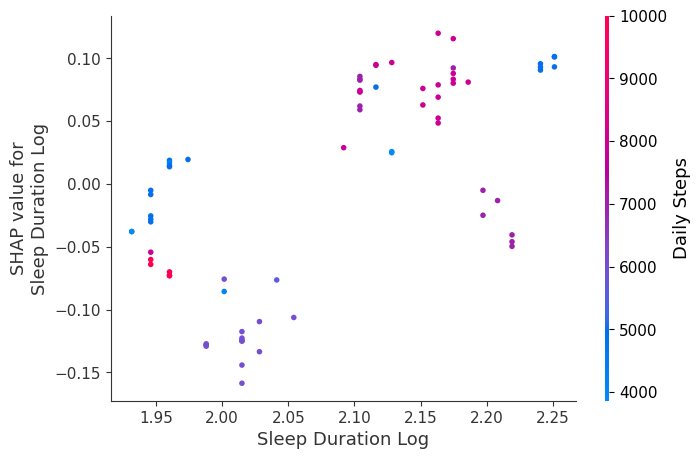

In [88]:
# TODO: run this line of code to display the dependence plot for that feature

# NOTE: if you have multiple classes, replace shap_values.values with shap_values.values[..., {class_index}]
shap.dependence_plot(feature, shap_values.values[...,0], X_test)

What do you notice about the SHAP values as the feature value increases/decreases (numerical) or goes from one class to the other (categorical). Write down any observations.

Notice the interaction feature that the dependence plot adds? How does this interaction feature affect how the feature that you chose sways the model predictions?

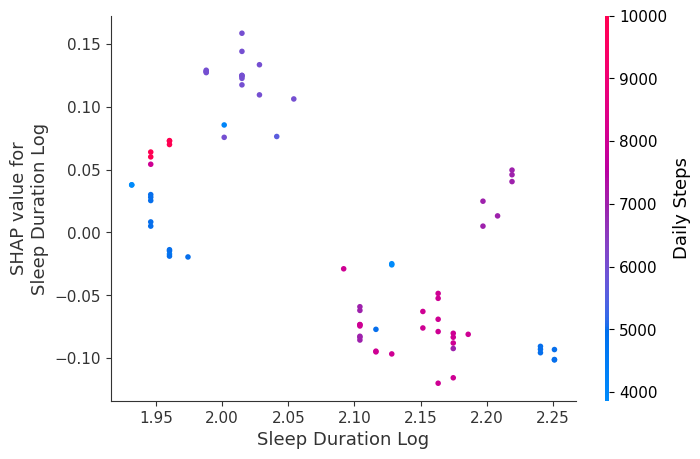

In [89]:
# TODO: Create more of these dependence plots for any features of interest
shap.dependence_plot(feature, shap_values.values[...,1], X_test)


### Exercise 4: Global SHAP Visualizations and Feature Importances

We will create two SHAP visualizations: a beeswarm and violin plot

/tmp/ipykernel_1068/406386349.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[...,0])


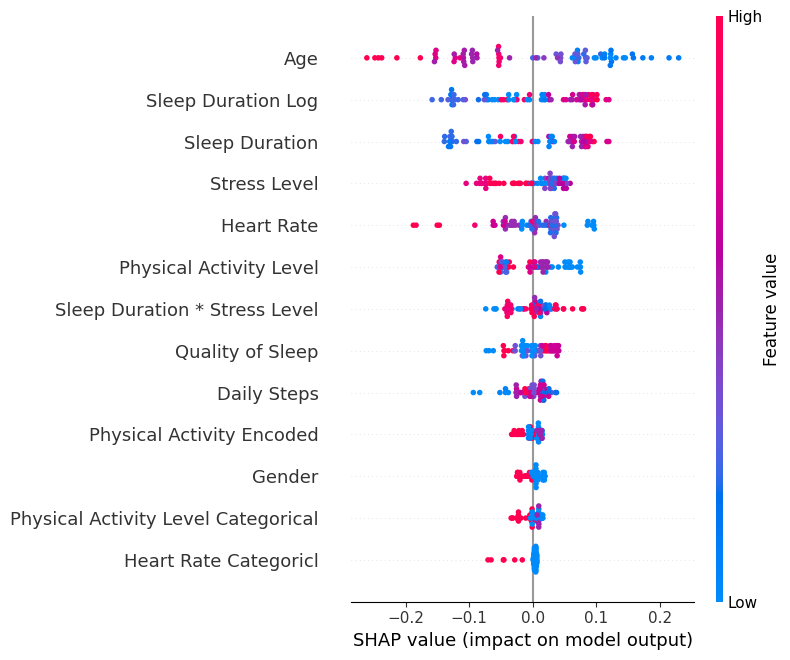

In [90]:
# TODO: Create a beeswarm plot of features and importances using shap.summary_plot()
shap.summary_plot(shap_values[...,0])

The top features are the most important features for the model predictions on a global scale. What are the top 2 most important features for this model.

Write an interpretation of the top feature in this plot

/tmp/ipykernel_1068/3781494425.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[...,1], plot_type="layered_violin")
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1033: UserWarning: Not enough data in bin #2 for feature Daily Steps, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1033: UserWarning: Not enough data in bin #3 for feature Daily Steps, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1033: UserWarning: Not enough data in bin #5 for feature Daily Steps, so it'll be ignored. Try increasing the number of records to plot.
  warnings.warn(
/usr/local/lib/py

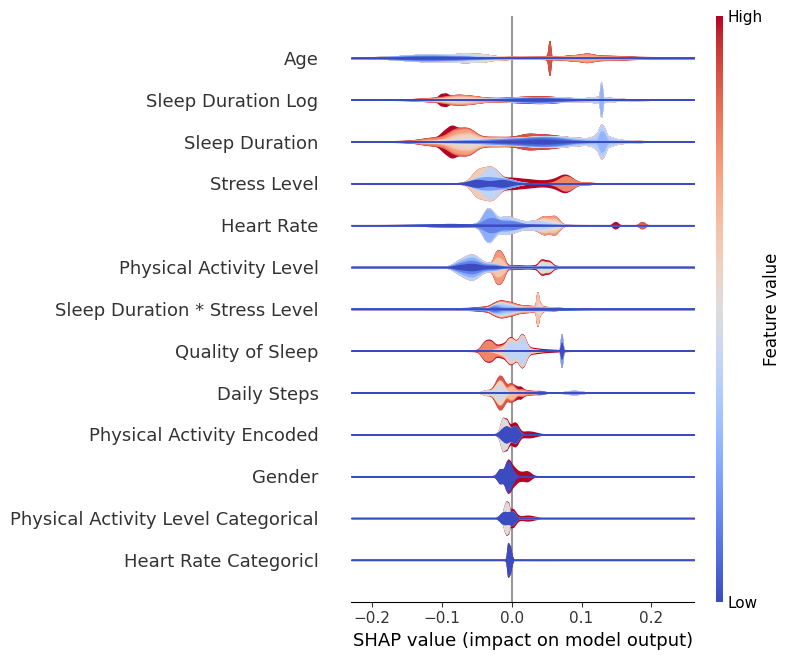

In [91]:
# TODO: Create a violin plot using shap.plots.violin (use plot_type="layered_violin")
shap.summary_plot(shap_values[...,1], plot_type="layered_violin")

In [100]:
# TODO: Create a violin plot using shap.plots.violin (use plot_type="layered_violin")
shap.summary_plot(shap_values[...,2], plot_type="layered_violin")

IndexError: index 2 is out of bounds for axis 2 with size 2

This plot replaces the individual dots in the beeswarm plot with a smoothed out density curve.

### Exercise 5: Prediction Specific Plots

Aside from the global plots, SHAP lets us understand how the features of a model affect a specific prediction

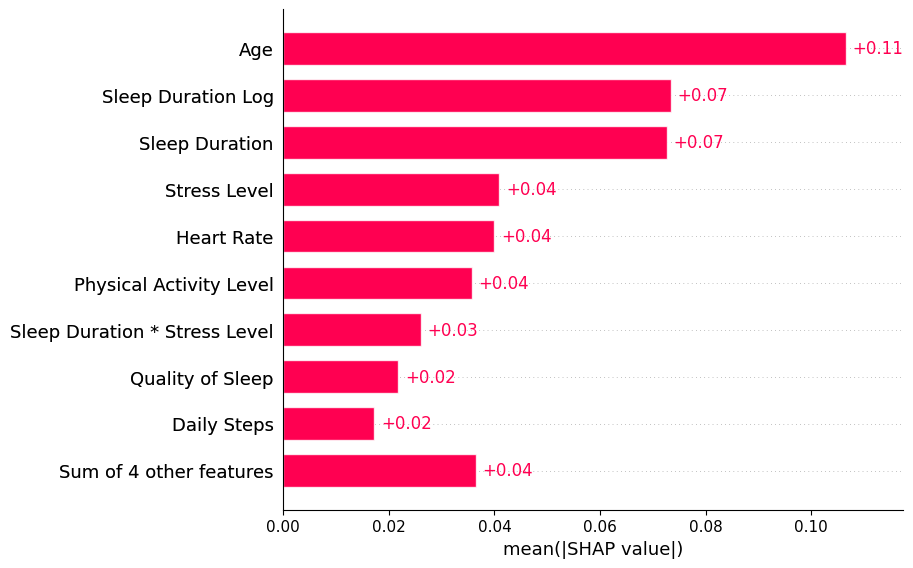

In [103]:
# TODO: Create a barplot for the first data point in the training set using shap.plots.bar()
# To get the first data point, use shap_values[0]
shap.plots.bar(shap_values[...,0])

Which feature has the most 'influence' in this models prediction? How much does it change the predicted probability of the model by?

In [108]:
''' TODO: Create a waterfall plot which calculates the expected predicted probability (baseline)
of the model and uses that to add up how the features affect that baseline. Create the plot
using the second data point in the training data. Use shap.plots.waterfall()
'''
shap.plots.waterfall(shap_values[1])

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (13, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

Write an interpretation for how the features affect the models output.

Why is it important to understand and interpret model outputs for use in healthcare settings?